# 딥러닝-CNN 모델링

MNIST 손글씨 숫자 데이터를 사용해 PyTorch 기반 CNN 모델을 만들고 비교합니다.

이 노트북의 목표는 다음과 같습니다.

- 이미지 데이터를 CNN 입력 형태인 `[batch, channel, height, width]`로 다룬다.
- `Conv2d`, `ReLU`, `MaxPool2d`, `Flatten`, `Linear`로 CNN 분류 모델을 구성한다.
- 다중분류 손실 함수인 `CrossEntropyLoss`를 사용한다.
- confusion matrix와 classification report로 모델을 평가한다.
- 틀린 예측 이미지를 확인하고, 직접 그린 손글씨 이미지를 예측한다.

## 0. CNN이란?

| 개념 | 역할 |
|---|---|
| **Conv2d (합성곱)** | 작은 커널을 이미지 위에서 슬라이딩하며 국소 패턴을 감지 |
| **활성화 (ReLU)** | 비선형성 추가 |
| **Pooling** | 공간 크기 축소 + 위치 변화에 둔감 |
| **Flatten + FC** | 추출된 특징을 가지고 최종 분류 |


### 왜 MLP 대신 CNN 인가
1. **파라미터 공유** — 같은 커널이 이미지 전체를 훑음. MLP보다 훨씬 적은 파라미터.
2. **위치 불변성** — 고양이가 왼쪽 위에 있든 오른쪽 아래에 있든 같은 패턴으로 인식.
3. **계층적 학습** — 저층은 엣지·색상, 중층은 부품, 고층은 객체.

In [1]:
# Colab 한글 폰트 설치
!sudo apt-get install -y fonts-nanum
!sudo fc-cache -fv
!rm ~/.cache/matplotlib -rf

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
fonts-nanum is already the newest version (20200506-1).
0 upgraded, 0 newly installed, 0 to remove and 3 not upgraded.
/usr/share/fonts: caching, new cache contents: 0 fonts, 1 dirs
/usr/share/fonts/truetype: caching, new cache contents: 0 fonts, 3 dirs
/usr/share/fonts/truetype/humor-sans: caching, new cache contents: 1 fonts, 0 dirs
/usr/share/fonts/truetype/liberation: caching, new cache contents: 16 fonts, 0 dirs
/usr/share/fonts/truetype/nanum: caching, new cache contents: 12 fonts, 0 dirs
/usr/local/share/fonts: caching, new cache contents: 0 fonts, 0 dirs
/root/.local/share/fonts: skipping, no such directory
/root/.fonts: skipping, no such directory
/usr/share/fonts/truetype: skipping, looped directory detected
/usr/share/fonts/truetype/humor-sans: skipping, looped directory detected
/usr/share/fonts/truetype/liberation: skipping, looped directory detected
/usr/share/fonts/truetype/n

In [2]:
import numpy as np
import matplotlib.pyplot as plt

# Colab용 한글 폰트 설정
plt.rcParams['font.family'] = 'NanumGothic'
plt.rcParams['axes.unicode_minus'] = False

### [참고] 커널이 진짜 뭘 하나(1D Conv 직관)
- 2D Conv가 어렵게 느껴지면 1D 신호로 보면 명료해집니다. 커널은 신호 위를 슬라이딩하며 자기 모양과 닮은 부분에서 강하게 반응합니다.

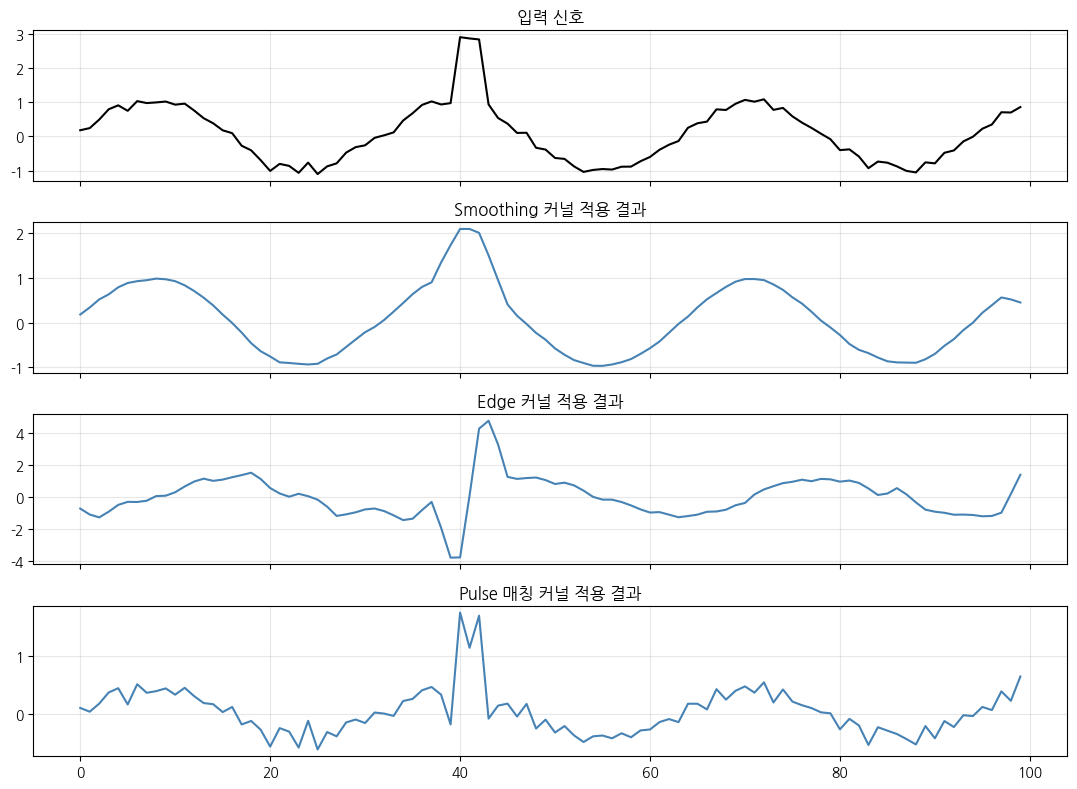

In [3]:
# 1D 신호 (사인 + 단발 펄스)
np.random.seed(0)
t = np.arange(100)
signal = np.sin(t * 0.2)
signal[40:43] = 3.0           # 펄스 (이상치 같은 패턴)
signal += 0.1 * np.random.randn(100)

# 커널 3개
k_smooth = np.array([0.2, 0.2, 0.2, 0.2, 0.2])     # 평균 — 노이즈 제거
k_edge = np.array([-1, -1, 0, 1, 1])                # 엣지 검출 — 변화 지점 강조
k_pulse = np.array([0, -0.3, 1.0, -0.3, 0])         # 단발 펄스 매칭

def conv1d(sig, kern):
    return np.convolve(sig, kern, mode='same')

fig, axes = plt.subplots(4, 1, figsize=(11, 8), sharex=True)
axes[0].plot(t, signal, color='black'); axes[0].set_title('입력 신호')
axes[0].grid(alpha=0.3)
for ax, name, k in zip(axes[1:], ['Smoothing 커널', 'Edge 커널', 'Pulse 매칭 커널'],
                      [k_smooth, k_edge, k_pulse]):
    out = conv1d(signal, k)
    ax.plot(t, out, color='steelblue')
    ax.set_title(f'{name} 적용 결과')
    ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

- 해석:
    - Smoothing: 출력이 부드러워짐 (노이즈 줄음)
    - Edge: 신호가 급변하는 지점(40 부근 펄스 시작/끝)에서 큰 값
    - Pulse 매칭: 펄스 위치에서 가장 강한 반응 — 이 패턴이 여기 있다

- CNN의 학습된 필터들은 자동으로 이런 패턴 매칭기가 됩니다
- 단지 사람이 정한 게 아니라 데이터에서 배운 것입니다.

## 1. 환경 준비

필요한 라이브러리를 불러오고, 반복해서 사용할 함수들을 먼저 정의합니다.

### 1.1 라이브러리 불러오기

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import *
from sklearn.preprocessing import StandardScaler, MinMaxScaler, LabelEncoder

In [2]:
import torch
from torch import nn
from torch.utils.data import DataLoader, TensorDataset
from torch.optim import Adam
from torchvision import datasets
from torchvision.transforms import ToTensor

- 모델 요약 도구
    - `torchsummary`가 설치되어 있으면 CNN 레이어별 출력 크기와 파라미터 수를 확인할 수 있습니다.

In [6]:
# 설치가 필요한 경우 라이브러리 설치합니다.
# %pip install torchsummary

In [3]:
from torchsummary import summary

### 1.2 필요 함수 생성

아래 함수들이 학습 흐름의 핵심입니다.

- `make_DataSet`: numpy/pandas 데이터를 학습용 `DataLoader`와 검증 텐서로 변환합니다.
- `train`: 한 epoch 동안 미니배치 학습을 수행합니다.
- `evaluate`: 검증 또는 테스트 데이터 전체에 대해 손실과 예측값을 반환합니다.
- `dl_learning_curve`: train loss와 validation loss 변화를 시각화합니다.

- `make_DataSet` 함수 : 딥러닝을 위한 데이터로더 만들기

In [4]:
def make_DataSet(x_train, x_val, y_train, y_val, batch_size=32):
    """pandas/numpy 데이터를 PyTorch 학습용 DataLoader와 검증 텐서로 변환합니다."""

    # 데이터 텐서로 변환
    x_train_tensor = torch.tensor(np.array(x_train), dtype=torch.float32)
    y_train_tensor = torch.tensor(np.array(y_train), dtype=torch.long)
    x_val_tensor = torch.tensor(np.array(x_val), dtype=torch.float32)
    y_val_tensor = torch.tensor(np.array(y_val), dtype=torch.long)

    # TensorDataset 생성 : 텐서 데이터셋으로 합치기
    train_dataset = TensorDataset(x_train_tensor, y_train_tensor)

    # DataLoader 생성
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)

    return train_loader, x_val_tensor, y_val_tensor

- `train` 함수 : 학습을 위한 함수

In [5]:
def train(dataloader, model, loss_fn, optimizer, device):
    """한 epoch 동안 모델을 학습하고 평균 train loss를 반환합니다."""
    model.train()                               # 훈련 모드로 설정
    total_loss = 0

    for x, y in dataloader:                # (x, y) : 입력 데이터와 레이블
        x, y = x.to(device), y.to(device)  # 입력 데이터와 레이블을 지정된 장치(device, CPU 또는 GPU)로 이동

        # Feed Forward
        optimizer.zero_grad()              # 이전 배치의 gradient를 초기화
        pred = model(x)
        loss = loss_fn(pred, y)

        # Backpropagation
        loss.backward()                    # 역전파를 통해 모델의 각 파라미터에 대한 손실의 기울기를 계산
        optimizer.step()                   # 옵티마이저가 계산된 기울기를 사용하여 모델의 파라미터를 업데이트

        total_loss += loss.item() * x.size(0)  # 배치 평균 loss에 배치 크기를 곱해 배치 전체 loss로 누적

    return total_loss / len(dataloader.dataset)  # 전체 데이터 개수로 나누어 epoch 평균 loss 반환

- `evaluate` 함수 : 검증을 위한 함수

In [6]:
def evaluate(x_val_tensor, y_val_tensor, model, loss_fn, device):
    """검증/테스트 데이터 전체에 대한 loss와 예측값을 반환합니다."""

    model.eval()  # 모델을 평가 모드로 설정

    with torch.no_grad():  # 평가 과정에서는 기울기를 계산하지 않음
        x = x_val_tensor.to(device)
        y = y_val_tensor.to(device)
        pred = model(x)
        eval_loss = loss_fn(pred, y).item()

    return eval_loss, pred

- 학습 곡선

In [7]:
def dl_learning_curve(tr_loss_list, val_loss_list):
    epochs = range(1, len(tr_loss_list) + 1)

    plt.figure(figsize=(7, 4))
    plt.plot(epochs, tr_loss_list, label="train_loss", marker=".")
    plt.plot(epochs, val_loss_list, label="val_loss", marker=".")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend()
    plt.grid(alpha=0.3)
    plt.show()

### 1.3 Device 준비

GPU가 있으면 GPU를 사용하고, 없으면 CPU를 사용합니다.

In [8]:
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using {device} device")

Using cuda device


### 1.4 데이터 셋

MNIST는 0부터 9까지의 손글씨 숫자 이미지 데이터입니다.

- 입력 데이터: 28 x 28 흑백 이미지
- 정답 데이터: 숫자 클래스 0 ~ 9
- 클래스 개수: 10개

- 데이터 다운로드

In [9]:
# Download training data from open datasets.
train_dataset = datasets.MNIST(
    root="data",
    train=True,
    download=True,
    transform=ToTensor(),  # 픽셀값을 [0, 1] 사이로 정규화하고 텐서로 변환
)

# Download test data from open datasets.
test_dataset = datasets.MNIST(
    root="data",
    train=False,
    download=True,
    transform=ToTensor(),
)

100%|██████████| 9.91M/9.91M [00:00<00:00, 17.8MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 483kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 4.44MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 6.36MB/s]


- 데이터셋 일반 정보

In [10]:
train_dataset, test_dataset

(Dataset MNIST
     Number of datapoints: 60000
     Root location: data
     Split: Train
     StandardTransform
 Transform: ToTensor(),
 Dataset MNIST
     Number of datapoints: 10000
     Root location: data
     Split: Test
     StandardTransform
 Transform: ToTensor())

- 데이터셋의 x와 y

In [11]:
train_dataset.data.shape, train_dataset.targets.shape

(torch.Size([60000, 28, 28]), torch.Size([60000]))

- y(target)의 클래스

In [12]:
train_dataset.classes

['0 - zero',
 '1 - one',
 '2 - two',
 '3 - three',
 '4 - four',
 '5 - five',
 '6 - six',
 '7 - seven',
 '8 - eight',
 '9 - nine']

- 데이터 1건 확인

In [13]:
# 첫 번째 요소 : 이미지 데이터(1 x 28 x 28)
# 두 번째 요소 : 정답(레이블)
train_dataset[0]

(tensor([[[0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000],
          [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000],
          [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000],
          [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 

- 데이터 이미지 확인

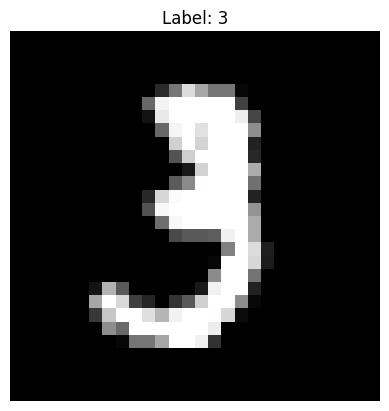

In [14]:
n = 10
image, label = train_dataset.data[n], train_dataset.targets[n]

# 이미지 시각화
plt.imshow(image, cmap="gray")
plt.title(f"Label: {label}")
plt.axis("off")
plt.show()

## 2. 데이터 준비

다운로드한 MNIST 데이터셋은 이미 다음 전처리가 적용되어 있습니다.

- x, y가 분리되어 있음
- train, test가 분리되어 있음
- `ToTensor()`를 통해 학습 데이터의 픽셀값이 [0, 1] 범위로 변환되어 있음

### 2.1 train은 DataLoader로 생성

학습 데이터는 미니배치 단위로 학습할 수 있도록 `DataLoader`로 만듭니다.

In [15]:
batch_size = 64
train_dataloader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)

In [16]:
# 첫번째 배치만 로딩해서 살펴보기
for x, y in train_dataloader:
    print(f"Shape of x [batch, channels, height, width]: {x.shape}")
    print(f"Shape of y: {y.shape} {y.dtype}")
    break

Shape of x [batch, channels, height, width]: torch.Size([64, 1, 28, 28])
Shape of y: torch.Size([64]) torch.int64


### 2.2 validation, test 준비

`test_dataset`을 validation과 test로 나누어 사용합니다.

- validation : 학습 중 epoch마다 성능 확인
- test : 모델 학습 후 최종 평가

`dataset.data` 속성으로 꺼낸 데이터는 원본 픽셀값이므로 모델링 전에 다음 처리를 수행합니다.

- 스케일링 : 0 ~ 255 값을 0 ~ 1 범위로 변환
- 차원 변환 : `[데이터 수, 28, 28]`에서 `[데이터 수, 1, 28, 28]`로 변환

- 데이터 분할 : test → validation, test

In [17]:
X_val, X_test = test_dataset.data[:5000], test_dataset.data[5000:]
y_val, y_test = test_dataset.targets[:5000], test_dataset.targets[5000:]

In [18]:
X_val.shape, y_val.shape

(torch.Size([5000, 28, 28]), torch.Size([5000]))

- 스케일링

In [19]:
X_val = X_val / 255
X_test = X_test / 255

- 3차원 데이터셋 → 4차원 데이터셋

CNN의 입력은 `[데이터 수, 채널 수, 세로, 가로]` 형태입니다. MNIST는 흑백 이미지이므로 채널 수는 1입니다.

In [20]:
X_val = X_val.view(5000, 1, 28, 28)
X_test = X_test.view(5000, 1, 28, 28)

print(X_val.shape, X_test.shape)

torch.Size([5000, 1, 28, 28]) torch.Size([5000, 1, 28, 28])


## 3. 모델링 1: 기본 CNN 모델 만들기

- CNN 모델의 기본 구조 특징은 다음과 같습니다.

    - `Conv2d`: 이미지에서 지역적 특징 추출
    - `ReLU`: 비선형성 추가
    - `MaxPool2d`: 특징 맵 크기 축소
    - `Flatten`: 분류기 입력을 위해 1차원으로 펼치기
    - `Linear`: 클래스별 점수 출력

### 3.1 모델 선언

In [ ]:
n_class = 10

# 모델 구조 설계
model1 = nn.Sequential(
    nn.Conv2d(1,8, kernel_size=3, padding=1), # input = 1*28*28, output = 8*28*28
    nn.ReLU(),
    nn.MaxPool2d(kernel_size=2, stride=2, padding=0),
    nn.Flatten(),
    nn.Linear(8*14*14, 64),
    nn.ReLU(),
    nn.Linear(64, n_class)
).to(device)

# 토치 모델 요약
summary(model1, input_size=(1,28,28))

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1            [-1, 8, 28, 28]              80
              ReLU-2            [-1, 8, 28, 28]               0
         MaxPool2d-3            [-1, 8, 14, 14]               0
           Flatten-4                 [-1, 1568]               0
            Linear-5                   [-1, 64]         100,416
              ReLU-6                   [-1, 64]               0
            Linear-7                   [-1, 10]             650
Total params: 101,146
Trainable params: 101,146
Non-trainable params: 0
----------------------------------------------------------------
Input size (MB): 0.00
Forward/backward pass size (MB): 0.12
Params size (MB): 0.39
Estimated Total Size (MB): 0.51
----------------------------------------------------------------


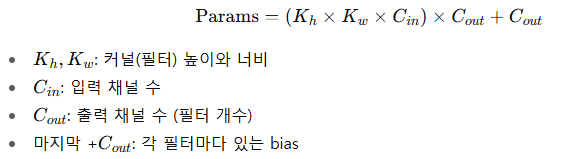

- Loss function과 Optimizer

In [24]:
loss_fn = nn.CrossEntropyLoss()
optimizer = Adam(model1.parameters(), lr=0.001)

### 3.2 모델 학습

In [25]:
epochs = 10
tr_loss_list, val_loss_list = [], []

for t in range(epochs):
    tr_loss = train(train_dataloader, model1, loss_fn, optimizer, device)
    val_loss, _ = evaluate(X_val, y_val, model1, loss_fn, device)

    # 리스트에 loss 추가 --> learning curve 그리기 위해.
    tr_loss_list.append(tr_loss)
    val_loss_list.append(val_loss)

    print(f"Epoch {t+1}, train loss : {tr_loss:.4f}, val loss : {val_loss:.4f}")

Epoch 1, train loss : 0.3399, val loss : 0.1963
Epoch 2, train loss : 0.1243, val loss : 0.1257
Epoch 3, train loss : 0.0844, val loss : 0.0989
Epoch 4, train loss : 0.0654, val loss : 0.0955
Epoch 5, train loss : 0.0548, val loss : 0.0907
Epoch 6, train loss : 0.0452, val loss : 0.0784
Epoch 7, train loss : 0.0383, val loss : 0.0845
Epoch 8, train loss : 0.0327, val loss : 0.0788
Epoch 9, train loss : 0.0275, val loss : 0.0760
Epoch 10, train loss : 0.0232, val loss : 0.0766


- 학습 곡선

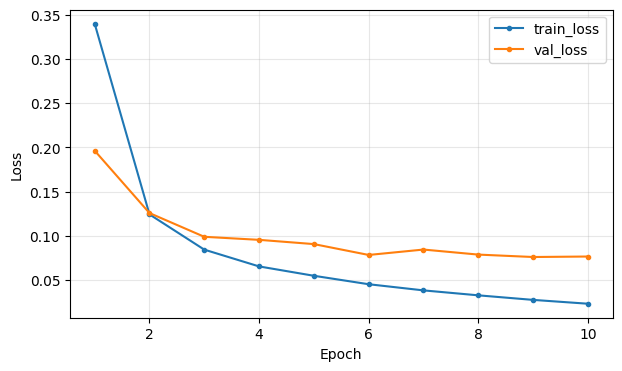

In [26]:
dl_learning_curve(tr_loss_list, val_loss_list)

### 3.3 모델 평가

In [29]:
_, pred = evaluate(X_test, y_test, model1, loss_fn, device)
_, pred

(0.030850479379296303,
 tensor([[-14.8276,  -6.8926,  -5.8615,  ...,  -9.7776,   0.7078,   0.7848],
         [ -5.2230, -17.6741,  -5.4609,  ...,  -5.2989,   3.5877,  13.0932],
         [ -8.4498, -16.1046, -10.1393,  ...,  -2.4370,   1.1398,  14.7579],
         ...,
         [ -8.8389,  -7.2917, -12.4247,  ...,   2.7109,   0.8206,   3.9898],
         [ -8.9194, -15.1165, -16.0919,  ...,  -7.6412,   6.7864,  -5.3242],
         [ -0.7183, -10.0132,  -4.3503,  ..., -13.7445,  -2.3505,  -7.9833]],
        device='cuda:0'))

- 예측 결과를 각 클래스별 확률값으로 변환 : `nn.functional.softmax()`
- 가장 확률이 높은 클래스 찾기 : `np.argmax()`

In [30]:
pred_prob = nn.functional.softmax(pred, dim=1)
pred_class = np.argmax(pred_prob.cpu().numpy(), axis=1)  # GPU에서 계산했다면 CPU로 변환 후 numpy 연산


- confusion matrix

In [31]:
cm = confusion_matrix(y_test.numpy(), pred_class)
cm

array([[514,   0,   0,   3,   0,   1,   1,   0,   1,   0],
       [  0, 562,   0,   0,   0,   0,   2,   0,   0,   0],
       [  0,   3, 492,   3,   0,   0,   1,   1,   2,   0],
       [  0,   0,   0, 507,   0,   0,   0,   1,   1,   1],
       [  0,   0,   0,   0, 479,   0,   0,   1,   0,   2],
       [  1,   0,   0,   1,   0, 433,   1,   0,   0,   0],
       [  0,   0,   0,   0,   2,   0, 494,   0,   0,   0],
       [  1,   1,   4,   1,   0,   0,   0, 508,   0,   1],
       [  0,   0,   1,   0,   0,   2,   0,   0, 479,   3],
       [  0,   0,   0,   1,   0,   0,   0,   1,   0, 487]])

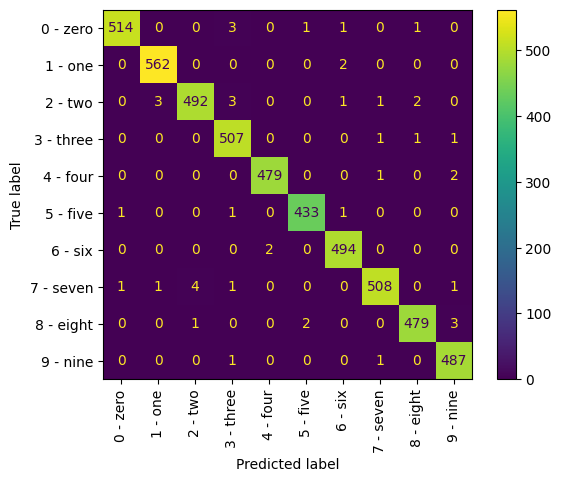

In [32]:
# confusion matrix 시각화
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=train_dataset.classes)
disp.plot()
plt.xticks(rotation=90)
plt.show()

- classification_report

In [33]:
print(accuracy_score(y_test.numpy(), pred_class))
print('-' * 100)
print(classification_report(y_test.numpy(), pred_class))

0.991
----------------------------------------------------------------------------------------------------
              precision    recall  f1-score   support

           0       1.00      0.99      0.99       520
           1       0.99      1.00      0.99       564
           2       0.99      0.98      0.98       502
           3       0.98      0.99      0.99       510
           4       1.00      0.99      0.99       482
           5       0.99      0.99      0.99       436
           6       0.99      1.00      0.99       496
           7       0.99      0.98      0.99       516
           8       0.99      0.99      0.99       485
           9       0.99      1.00      0.99       489

    accuracy                           0.99      5000
   macro avg       0.99      0.99      0.99      5000
weighted avg       0.99      0.99      0.99      5000



---

## 4. 모델링 2: CNN 모델 깊게 만들기

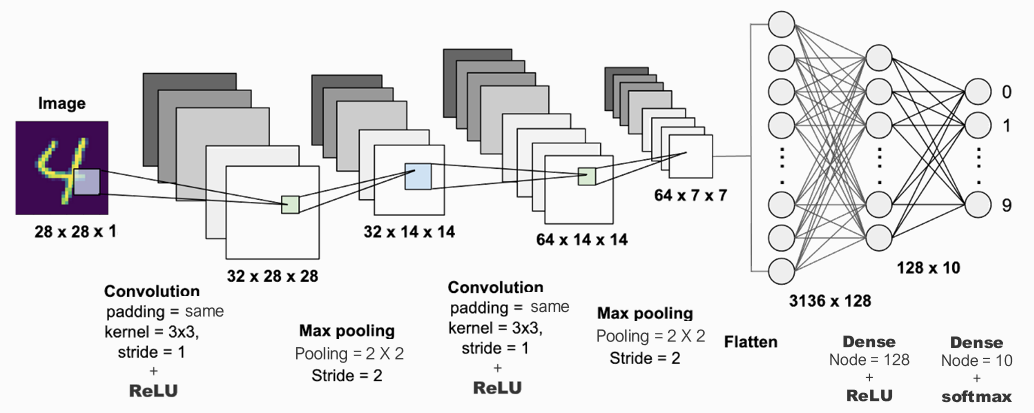

- 두 개의 convolution block을 사용해 더 많은 이미지 특징을 추출합니다.

    - 첫 번째 block: `Conv2d(1 → 32)` → `ReLU` → `MaxPool2d`
    - 두 번째 block: `Conv2d(32 → 64)` → `ReLU` → `MaxPool2d`
    - 분류기: `Flatten` → `Linear` → `ReLU` → `Linear`

### 4.1 모델 선언

In [36]:
n_class = 10

# 모델 구조 설계
model2 = nn.Sequential(
    nn.Conv2d(1,32, kernel_size=3, stride=1, padding=1),
    nn.ReLU(),
    nn.MaxPool2d(kernel_size=2, stride=2),          # 일반적으로 kernel_size와 stride 동일하게, 둘이 겹치지 않게. output = 32*14*!4
    nn.Conv2d(32,64, kernel_size=3,stride=1, padding=1),
    nn.ReLU(),
    nn.MaxPool2d(kernel_size=2, stride=2),
    nn.Flatten(),
    nn.Linear(64*7*7, 128),
    nn.ReLU(),
    nn.Linear(128, n_class)
).to(device)

# 토치 모델 요약
summary(model2, input_size=(1,28,28))

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1           [-1, 32, 28, 28]             320
              ReLU-2           [-1, 32, 28, 28]               0
         MaxPool2d-3           [-1, 32, 14, 14]               0
            Conv2d-4           [-1, 64, 14, 14]          18,496
              ReLU-5           [-1, 64, 14, 14]               0
         MaxPool2d-6             [-1, 64, 7, 7]               0
           Flatten-7                 [-1, 3136]               0
            Linear-8                  [-1, 128]         401,536
              ReLU-9                  [-1, 128]               0
           Linear-10                   [-1, 10]           1,290
Total params: 421,642
Trainable params: 421,642
Non-trainable params: 0
----------------------------------------------------------------
Input size (MB): 0.00
Forward/backward pass size (MB): 0.67
Params size (MB): 1.61
Estimated T

- Loss function과 Optimizer

In [39]:
loss_fn = nn.CrossEntropyLoss()
optimizer = Adam(model2.parameters(), lr=0.001)

### 4.2 모델 학습

In [40]:
epochs = 20
tr_loss_list, val_loss_list = [], []

for t in range(epochs):
    tr_loss = train(train_dataloader, model2, loss_fn, optimizer, device)
    val_loss, _ = evaluate(X_val, y_val, model2, loss_fn, device)

    # 리스트에 loss 추가 --> learning curve 그리기 위해.
    tr_loss_list.append(tr_loss)
    val_loss_list.append(val_loss)

    print(f"Epoch {t+1}, train loss : {tr_loss:.4f}, val loss : {val_loss:.4f}")

Epoch 1, train loss : 0.1845, val loss : 0.0840
Epoch 2, train loss : 0.0512, val loss : 0.0539
Epoch 3, train loss : 0.0348, val loss : 0.0518
Epoch 4, train loss : 0.0262, val loss : 0.0462
Epoch 5, train loss : 0.0201, val loss : 0.0475
Epoch 6, train loss : 0.0158, val loss : 0.0433
Epoch 7, train loss : 0.0115, val loss : 0.0388
Epoch 8, train loss : 0.0105, val loss : 0.0490
Epoch 9, train loss : 0.0089, val loss : 0.0546
Epoch 10, train loss : 0.0072, val loss : 0.0649
Epoch 11, train loss : 0.0061, val loss : 0.0734
Epoch 12, train loss : 0.0042, val loss : 0.0522
Epoch 13, train loss : 0.0061, val loss : 0.0537
Epoch 14, train loss : 0.0050, val loss : 0.0629
Epoch 15, train loss : 0.0042, val loss : 0.0773
Epoch 16, train loss : 0.0039, val loss : 0.0617
Epoch 17, train loss : 0.0030, val loss : 0.0731
Epoch 18, train loss : 0.0027, val loss : 0.0679
Epoch 19, train loss : 0.0038, val loss : 0.0606
Epoch 20, train loss : 0.0045, val loss : 0.0624


- 학습 곡선

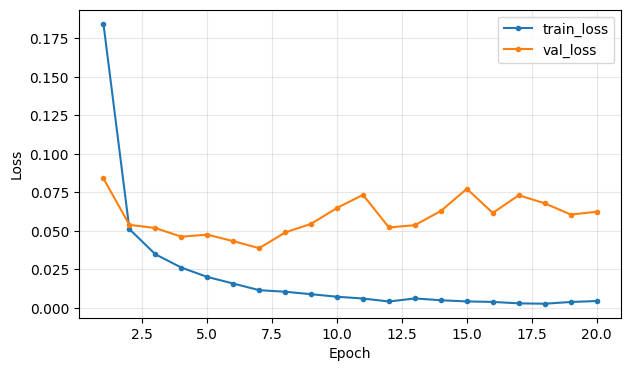

In [41]:
dl_learning_curve(tr_loss_list, val_loss_list)

### 4.3 모델 평가

In [42]:
_, pred = evaluate(X_test, y_test, model2, loss_fn, device)
pred[:5]

tensor([[-26.0505, -21.3960, -13.9058,  28.3949, -30.9583,   8.7317, -16.8783,
         -10.7923,   0.6787,  -6.2177],
        [-25.5857, -45.5489, -21.3504, -11.9452,   2.8705, -13.3105, -19.9022,
         -24.7596,   7.0160,  24.5980],
        [-21.6093, -26.0121, -22.8358,  -9.6937,  -2.3436,  -9.9345, -20.4407,
         -10.7054,  -4.6570,  24.9810],
        [-18.9650, -33.2916,  -5.6998,  -4.0038, -33.7824, -21.1031, -30.2916,
         -28.2682,  34.3346, -10.0001],
        [-25.6562, -24.5361, -17.2365, -29.3010,  33.5666, -14.4400, -23.7679,
         -13.3969,  -6.3106,  -7.0286]], device='cuda:0')

- 예측 결과를 각 클래스별 확률값으로 변환하고, 가장 확률이 높은 클래스를 최종 예측값으로 선택합니다.

In [43]:
pred_prob = nn.functional.softmax(pred, dim=1)
pred_class = np.argmax(pred_prob.cpu().numpy(), axis=1)
pred_class[:10]

array([3, 9, 9, 8, 4, 1, 0, 6, 0, 9])

- confusion matrix

In [44]:
cm = confusion_matrix(y_test.numpy(), pred_class)
cm

array([[517,   0,   0,   0,   0,   1,   1,   0,   0,   1],
       [  0, 563,   0,   0,   0,   0,   1,   0,   0,   0],
       [  0,   0, 499,   0,   0,   0,   0,   1,   1,   1],
       [  0,   0,   0, 509,   0,   1,   0,   0,   0,   0],
       [  0,   1,   0,   0, 480,   0,   0,   0,   0,   1],
       [  0,   0,   0,   1,   0, 434,   1,   0,   0,   0],
       [  0,   0,   0,   1,   1,   1, 493,   0,   0,   0],
       [  0,   2,   3,   0,   0,   0,   0, 510,   0,   1],
       [  0,   0,   0,   0,   1,   0,   0,   0, 484,   0],
       [  0,   0,   0,   0,   0,   2,   0,   1,   0, 486]])

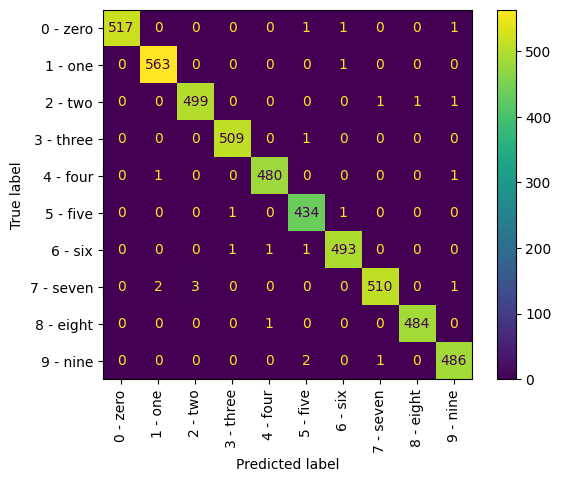

In [45]:
# confusion matrix 시각화
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=train_dataset.classes)
disp.plot()
plt.xticks(rotation=90)
plt.show()

- classification_report

In [46]:
print(accuracy_score(y_test.numpy(), pred_class))
print('-' * 100)
print(classification_report(y_test.numpy(), pred_class))

0.995
----------------------------------------------------------------------------------------------------
              precision    recall  f1-score   support

           0       1.00      0.99      1.00       520
           1       0.99      1.00      1.00       564
           2       0.99      0.99      0.99       502
           3       1.00      1.00      1.00       510
           4       1.00      1.00      1.00       482
           5       0.99      1.00      0.99       436
           6       0.99      0.99      0.99       496
           7       1.00      0.99      0.99       516
           8       1.00      1.00      1.00       485
           9       0.99      0.99      0.99       489

    accuracy                           0.99      5000
   macro avg       0.99      0.99      0.99      5000
weighted avg       1.00      0.99      1.00      5000



---

## 5. 틀린 그림 찾아보기

- 모델이 잘못 예측한 테스트 이미지를 골라 실제 정답과 예측값을 함께 확인합니다.

In [47]:
import random as rd

In [48]:
idx = (y_test.numpy() != pred_class)
X_test_wr = X_test[idx]
y_test_wr = y_test[idx]
pred_wr = pred_class[idx]

X_test_wr = X_test_wr.reshape(-1, 28, 28)
print(X_test_wr.shape)

torch.Size([25, 28, 28])


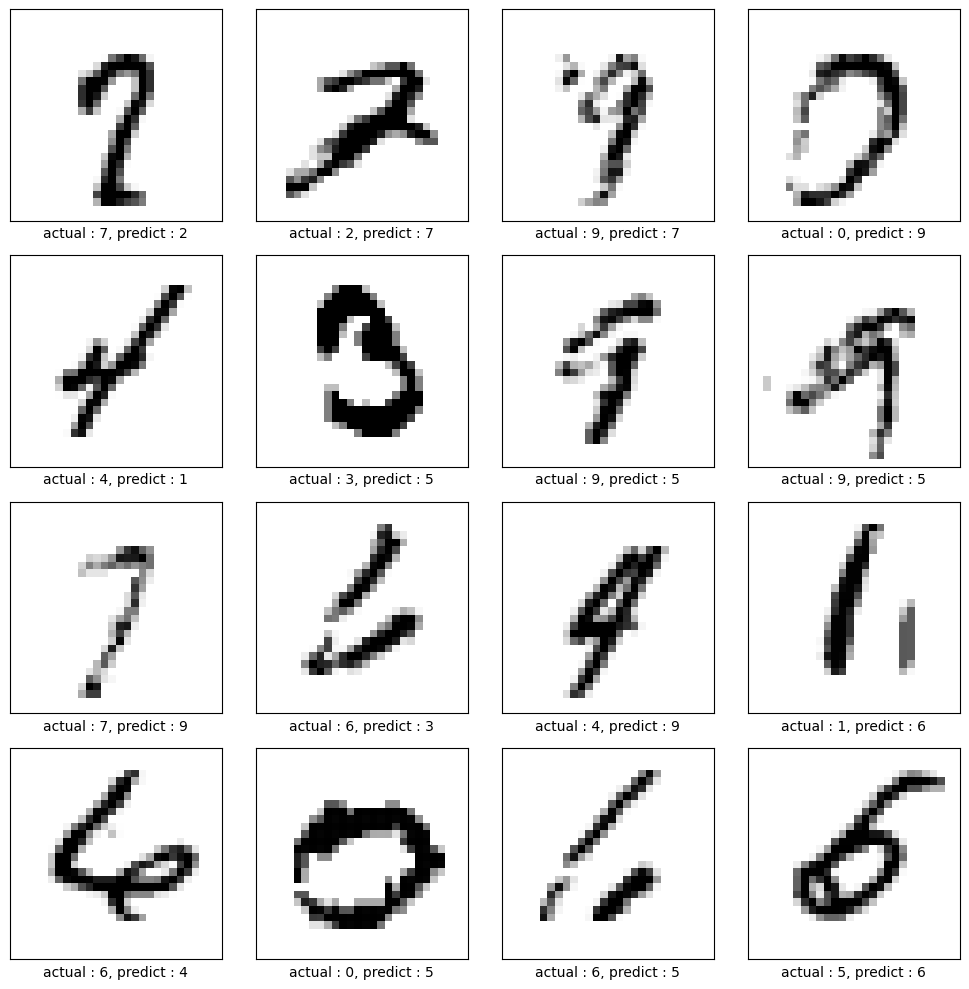

In [49]:
idx = rd.sample(range(X_test_wr.shape[0]), min(16, X_test_wr.shape[0]))
X_temp = X_test_wr[idx]
y_temp = y_test_wr[idx]
p_temp = pred_wr[idx]

plt.figure(figsize=(10, 10))
for i in range(len(idx)):
    plt.subplot(4, 4, i + 1)
    plt.xticks([])
    plt.yticks([])
    plt.imshow(X_temp[i], cmap=plt.cm.binary)
    plt.xlabel(f"actual : {y_temp[i]}, predict : {p_temp[i]}")
plt.tight_layout()
plt.show()

---

## 6. 진짜 손글씨로 예측해보기

- 직접 준비한 손글씨 이미지 파일을 MNIST와 같은 형태로 변환한 뒤, 학습된 CNN 모델로 숫자를 예측합니다.

    - 예시 파일명: `숫자_1.png`
    - 이미지가 없는 경우 파일명을 실제 이미지 경로로 변경해야 합니다.

### 6.1 데이터 준비

- 이미지 처리를 위한 라이브러리와 함수 불러오기

In [56]:
import cv2
from PIL import Image

- 구글 Colab용 코드

Saving 숫자_6.png to 숫자_6.png


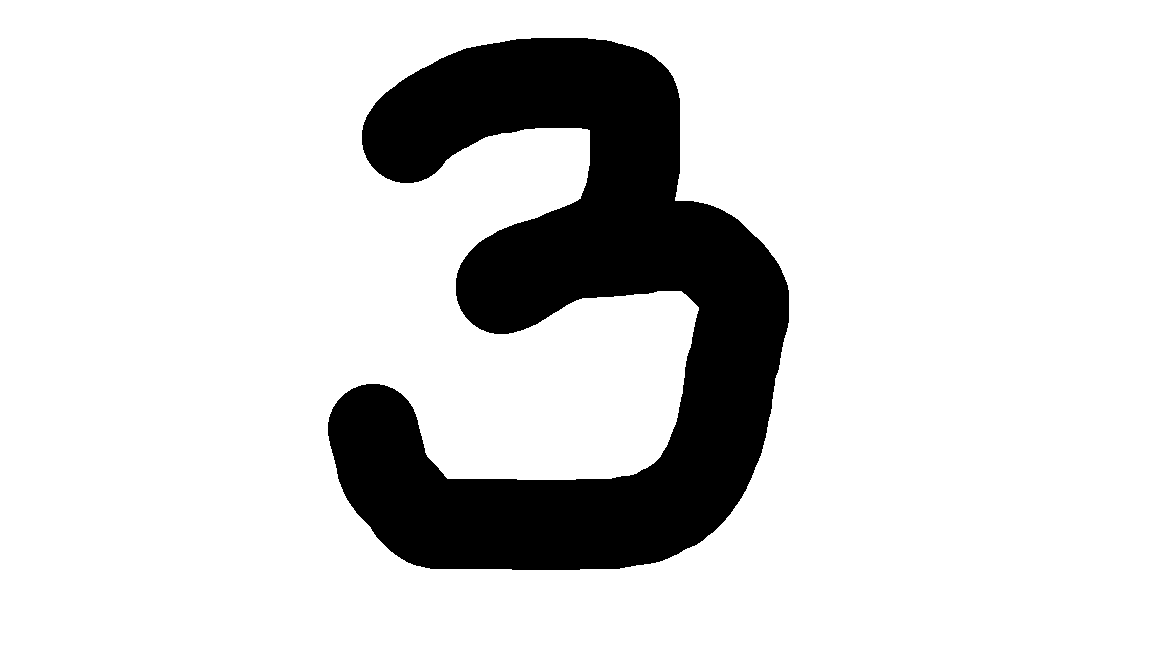

(648, 1152)


In [57]:
# Colab에서 사용할 경우 주석을 해제합니다.
from google.colab.patches import cv2_imshow
from google.colab import files
uploaded = files.upload()

# 그림 확인
img = cv2.imread(list(uploaded.keys())[0], cv2.IMREAD_GRAYSCALE)
cv2_imshow(img)
print(img.shape)

- 그림판에서 그린 손글씨 업로드

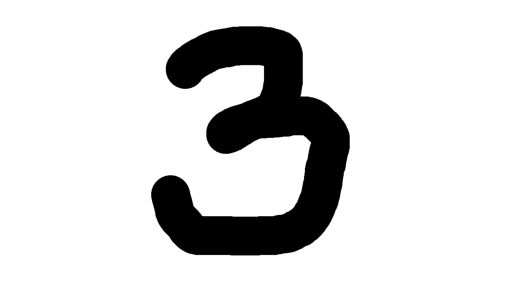

In [58]:
image_path = '숫자_6.png'

# 흰색 배경 → 검은색 배경으로 반전하기 위해 흑백 이미지로 변환
mage = Image.open(image_path).convert("L")
img = np.array(mage)
plt.imshow(img, cmap="gray")
plt.axis("off")
plt.show()

- 이미지 크기 조절하기

(28, 28)


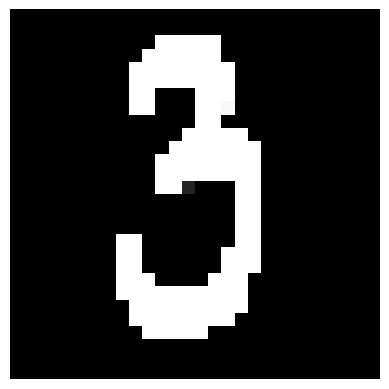

In [59]:
# 색 반전 후 MNIST 크기인 28 x 28로 조절
img = cv2.resize(255 - img, (28, 28))
print(img.shape)
plt.imshow(img, cmap="gray")
plt.axis("off")
plt.show()

In [60]:
# (1, 1, 28, 28)로 변환
new_data = img.reshape(1, 1, 28, 28)

# 스케일링
new_data = new_data / 255

# 텐서로 변환
new_data = torch.tensor(new_data, dtype=torch.float32)
new_data.shape

torch.Size([1, 1, 28, 28])

### 6.2 예측하기

In [61]:
model2.eval()
with torch.no_grad():
    new_data = new_data.to(device)
    pred = model2(new_data)
    pred_prob = nn.functional.softmax(pred, dim=1)
    pred_class = np.argmax(pred_prob.cpu().numpy(), axis=1)

pred_class

array([3])

### 6.3 함수로 만들기

In [62]:
def predict_number(model, image_path, device):
    mage = Image.open(image_path).convert("L")
    img = np.array(mage)

    # 1. 색 반전 후 크기 조절하기
    img = cv2.resize(255 - img, (28, 28))

    print("입력데이터")
    print(img.shape)
    print("-" * 50)
    plt.imshow(img, cmap="gray")
    plt.axis("off")
    plt.show()

    # 2. (1, 1, 28, 28)로 변환
    new_data = img.reshape(1, 1, 28, 28)

    # 3. 스케일링
    new_data = new_data / 255

    # 4. 텐서로 변환
    new_data = torch.tensor(new_data, dtype=torch.float32)

    # 5. 예측
    model.eval()
    with torch.no_grad():
        new_data = new_data.to(device)
        pred = model(new_data)
        pred_prob = nn.functional.softmax(pred, dim=1)
        pred_class = np.argmax(pred_prob.cpu().numpy(), axis=1)

    return pred_class[0]

입력데이터
(28, 28)
--------------------------------------------------


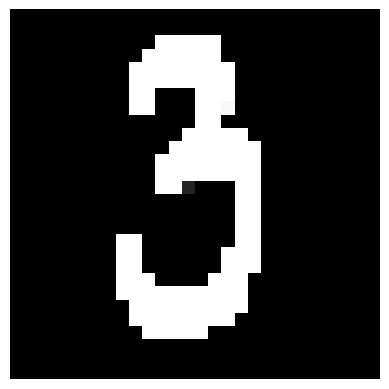

np.int64(3)

In [64]:
predict_number(model2, '숫자_6.png', device)